In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

repository = scarf.cytebase.connect("scarf_docs")

ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

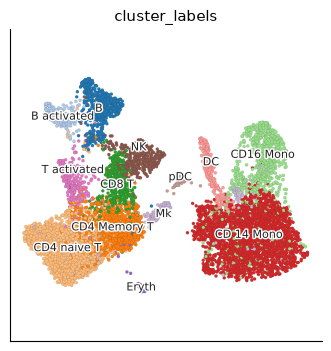

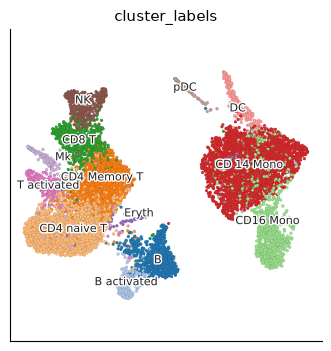

In [3]:
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)

In [4]:
run = ds_ctrl.pipeline.open(label="docs_default")
reference_layout = run["umap"]
reference_ref = ds_ctrl.build_mapping_reference(run["neighbors"])
reference = ds_ctrl.get_mapping_reference(reference_ref)

In [5]:
query_cell_selection = ds_stim.snapshot_cell_selection("I")
mapping_ref = ds_stim.run_mapping(
    reference,
    query_cell_selection,
    query_assay="RNA",
    save_k=5,
    missing_feature_policy="reference_mean",
)

In [6]:
mapping = ds_stim.get_mapping_result(
    mapping_ref,
    reference=reference,
    load_arrays=True,
)
mapping.n_cells, int(mapping.indices.shape[1]), mapping.indices[:3], mapping.distances[:3]

(10111,
 5,
 array([[2371, 5685,  672,  124, 1991],
        [5302, 4820, 6540, 1779, 2025],
        [7642, 1619, 5304, 7848, 8227]], dtype=uint64),
 array([[ 8.25005531,  9.43447113,  9.49619675, 10.0301075 , 10.36008549],
        [16.95982933, 19.03926468, 19.63176155, 20.06140518, 20.96114731],
        [ 7.37567759,  7.52598763,  8.10216808,  8.21979427,  8.24611187]]))

In [7]:
mapping.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'scaled_pca',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.3597154177596102}

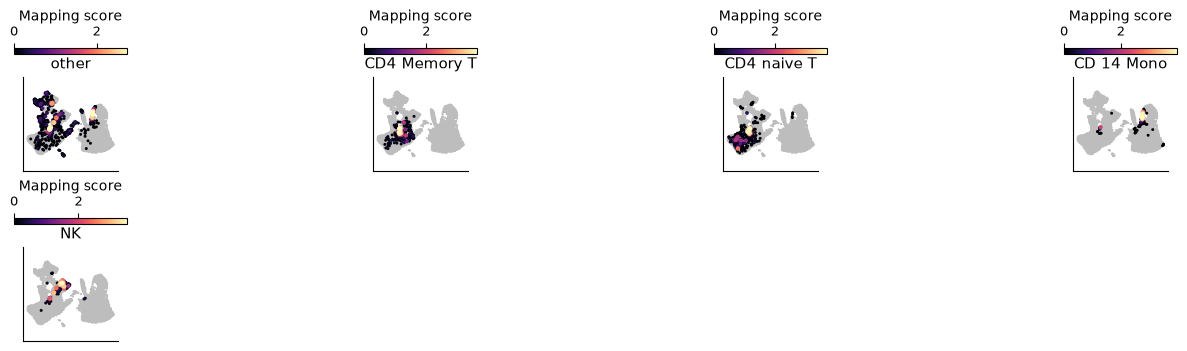

In [8]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
focus = {"CD 14 Mono", "CD4 Memory T", "CD4 naive T", "NK"}
score_groups = np.array(
    [label if label in focus else "other" for label in query_labels],
    dtype=object,
)
ds_stim.plots.mapping_score(
    mapping_ref,
    reference=reference,
    layout=reference_layout,
    target_groups=score_groups,
    size_by_score=True,
    figsize=(14, 3.4),
)

In [9]:
transferred_labels = ds_stim.get_target_classes(
    mapping_ref,
    reference_class_group="cluster_labels",
    reference=reference,
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "transferred_labels",
    transferred_labels.to_numpy(),
    overwrite=True,
)
accepted = transferred_labels.notna() & transferred_labels.ne("NA")
accepted.value_counts().rename(
    index={True: "accepted", False: "abstained"}
).rename("query cells")

accepted     8170
abstained    1941
Name: query cells, dtype: int64

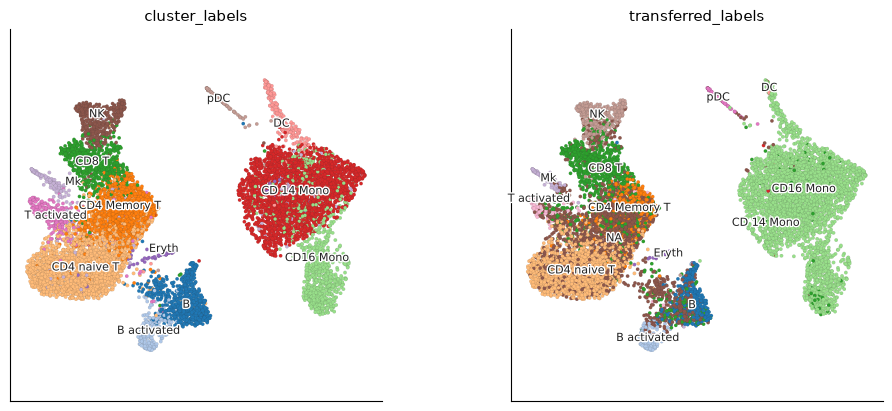

In [10]:
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["cluster_labels", "transferred_labels"],
    figsize=(10, 4),
)

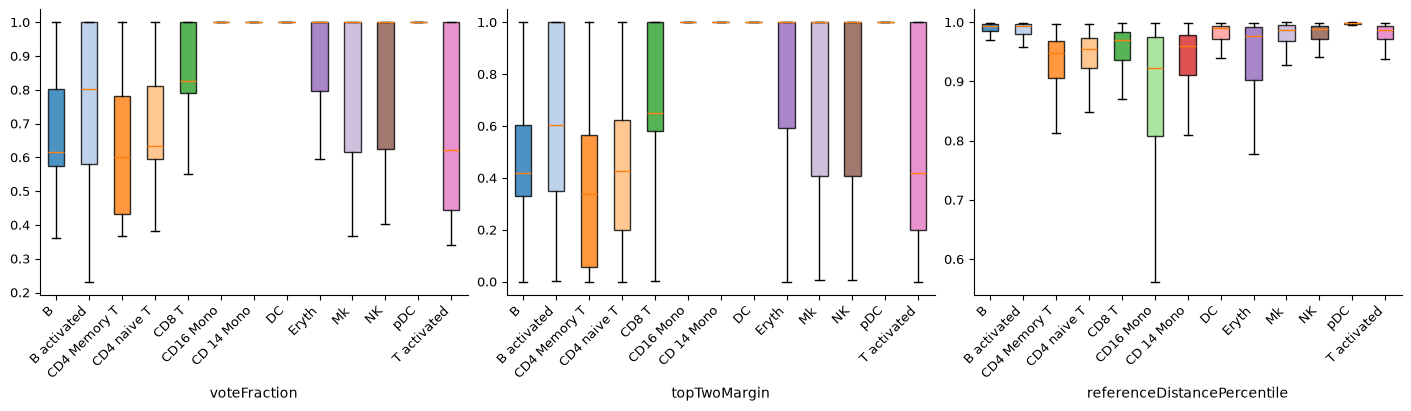

In [11]:
ds_stim.plots.mapping_evidence(
    mapping_ref,
    reference=reference,
    reference_class_group="cluster_labels",
    target_groups=query_labels,
    metrics=("voteFraction", "topTwoMargin", "referenceDistancePercentile"),
    kind="box",
    threshold_fraction=0.6,
    figsize=(14, 4),
)

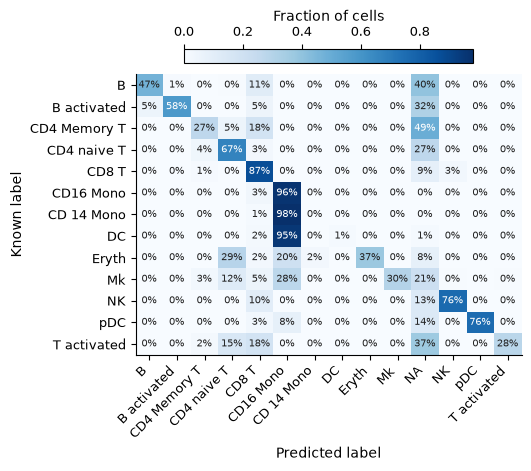

In [12]:
ds_stim.plots.mapping_confusion(
    mapping_ref,
    reference=reference,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

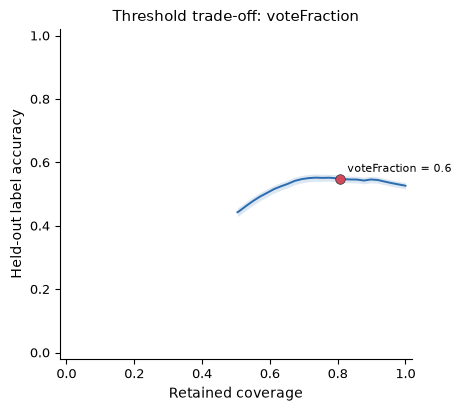

In [13]:
ds_stim.plots.mapping_calibration(
    mapping_ref,
    reference=reference,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    chosen_threshold=0.6,
)

In [14]:
focus_labels = ("CD 14 Mono", "CD16 Mono", "NK")
focus_groups = np.array(
    [label if label in focus_labels else "other" for label in query_labels],
    dtype=object,
)
ref_classes = np.asarray(
    reference.fetch_cell_column("cluster_labels"),
    dtype=object,
)
score_mass: dict[str, pd.Series] = {}
for group, values in ds_stim.get_mapping_score(
    mapping_ref,
    target_groups=focus_groups,
    reference=reference,
    log_transform=False,
):
    if group == "other":
        continue
    score_mass[str(group)] = (
        pd.Series(np.asarray(values, dtype=np.float64), index=ref_classes)
        .groupby(level=0, sort=False)
        .sum()
    )
score_mass_table = pd.DataFrame(
    {label: score_mass[label] for label in focus_labels if label in score_mass}
).fillna(0.0)
score_mass_table.loc[
    score_mass_table.max(axis=1).sort_values(ascending=False).index
].round(3)

,CD 14 Mono,CD16 Mono,NK
CD16 Mono,283.615,287.231,0.000
NK,0.022,0.049,216.467
CD8 T,2.325,5.279,55.952
CD4 naive T,0.856,1.838,5.669
Mk,0.541,1.234,0.123
CD4 Memory T,0.143,0.353,0.757
CD 14 Mono,0.382,0.000,0.645
B,0.000,0.000,0.521
pDC,0.000,0.000,0.000
T activated,0.000,0.000,0.000


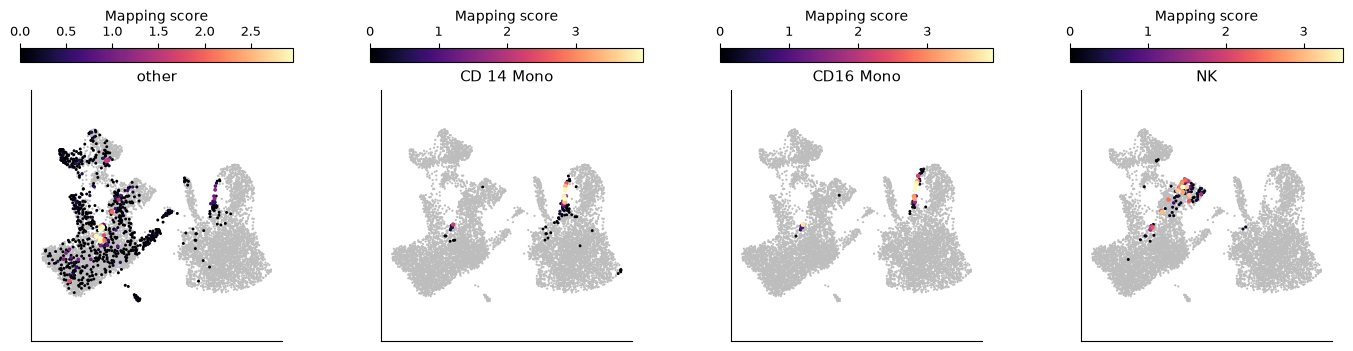

In [15]:
ds_stim.plots.mapping_score(
    mapping_ref,
    reference=reference,
    layout=reference_layout,
    target_groups=focus_groups,
    size_by_score=True,
    figsize=(14, 3.4),
)

In [16]:
reference = ds_ctrl.get_mapping_reference(reference_ref)
reloaded_mapping = ds_stim.get_mapping_result(
    mapping_ref,
    reference=reference,
)
reloaded_mapping.n_cells, reloaded_mapping.correction_method

(10111, 'none')